Let's start with a real qubit error 

In [2]:
pip install qiskit qiskit-ibm-runtime


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_ibm_runtime import QiskitRuntimeService, Sampler

In [7]:
import json

# 读取JSON文件
with open(r'D:\Quantum_studies\apikey.json', 'r') as f:
    data = json.load(f)


API_KEY = data['apikey']

from qiskit_ibm_runtime import QiskitRuntimeService
 
QiskitRuntimeService.save_account(
    token=API_KEY, # Use the 44-character API_KEY you created and saved from the IBM Quantum Platform Home dashboard
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/9b8bc3164f694c90b9e3e2b8be87175a:cf79926b-2b20-403b-9a23-d4aaf23cfbd7::", # Optional
    overwrite=True
    )

# Every time you need the service

from qiskit_ibm_runtime import QiskitRuntimeService

# Run every time you need the service
service = QiskitRuntimeService()


In [11]:
backend = service.least_busy(operational=True, simulator=False) 

In [17]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

# =====================================================================
# 构建你的主动纠错量子电路 (Active QEC Circuit)
# =====================================================================
q = QuantumRegister(5, 'q')
c_syn = ClassicalRegister(2, 'syndrome') # 存储中途测出来的错误信号
c_out = ClassicalRegister(1, 'output')   # 最终读取结果

qc = QuantumCircuit(q, c_syn, c_out)

# --------------- 编码阶段 (Encoding) ---------------
qc.x(q[0]) # 把 q[0] 变成 |1>，我们要保护它
qc.cx(q[0], q[1])
qc.cx(q[0], q[2])
qc.barrier()

# --------------- 错误发生阶段 (Error) ---------------
# 故意翻转 q[0]，模拟一个比特翻转错误
qc.x(q[0]) 
qc.barrier()

# --------------- 错误检测阶段 (Syndrome Measurement) ---------------
qc.cx(q[0], q[3])
qc.cx(q[1], q[3]) 
qc.cx(q[1], q[4])
qc.cx(q[2], q[4]) 

# 【中途测量】：这是 IBM 硬件的黑科技，在电路运行中间测出 0 和 1
qc.measure(q[3], c_syn[0])
qc.measure(q[4], c_syn[1])
qc.barrier()

# --------------- 实时主动纠错阶段 (Feed-forward) ---------------
# 根据中途测量测出的 Syndrome 进行实时的硬件级修正
with qc.if_test((c_syn, 1)):   # 如果 syndrome 是 01
    qc.x(q[0])                 # 当场修复 q[0]
with qc.if_test((c_syn, 2)):   # 如果 syndrome 是 10
    qc.x(q[2])                 # 当场修复 q[2]
with qc.if_test((c_syn, 3)):   # 如果 syndrome 是 11
    qc.x(q[1])                 # 当场修复 q[1]
qc.barrier()

# --------------- 最终检验 ---------------
qc.measure(q[0], c_out[0])


# =====================================================================
# 编译并发送到真实硬件 (兼容 Open Plan 免费账户的 V2 写法)
# =====================================================================

# 2. 编译电路 (ISA - Instruction Set Architecture)
# 这一步必须做！它会将你写的理想逻辑门，翻译成这台机器真实支持的物理门和拓扑结构
print("正在将电路编译至目标硬件架构...")
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_qc = pm.run(qc)

# 3. 初始化 SamplerV2 (不使用 Session，使用 mode=backend 模式)
sampler = Sampler(mode=backend)
# 设置运行次数 (shots)
sampler.options.default_shots = 1000

# 4. 提交任务到真机
print(f"正在向真机 {backend.name} 提交任务...")
# 注意：V2 版本的 run() 必须传入一个列表，即使只有一个电路
job = sampler.run([isa_qc]) 
print(f"提交成功！Job ID: {job.job_id()}")
print("你可以在 Dashboard 查看进度: https://quantum.cloud.ibm.com/jobs")

# 5. 等待并解析结果
print("正在等待真机运行结果（可能需要排队，请耐心等待）...")
result = job.result()
pub_result = result[0]

# 在 V2 版本中，不同寄存器的结果被分开存储了，提取非常方便
print("\n========== 真机运行结果 ==========")
print("最终保护结果 (Output register):", pub_result.data.output.get_counts())
print("中途捕捉到的错误信号 (Syndrome register):", pub_result.data.syndrome.get_counts())

正在将电路编译至目标硬件架构...
正在向真机 ibm_marrakesh 提交任务...
提交成功！Job ID: d6ikarcmmeis739qe7c0
你可以在 Dashboard 查看进度: https://quantum.cloud.ibm.com/jobs
正在等待真机运行结果（可能需要排队，请耐心等待）...

========== 真机运行结果 ==========
最终保护结果 (Output register): {'1': 924, '0': 76}
中途捕捉到的错误信号 (Syndrome register): {'01': 927, '11': 26, '10': 20, '00': 27}


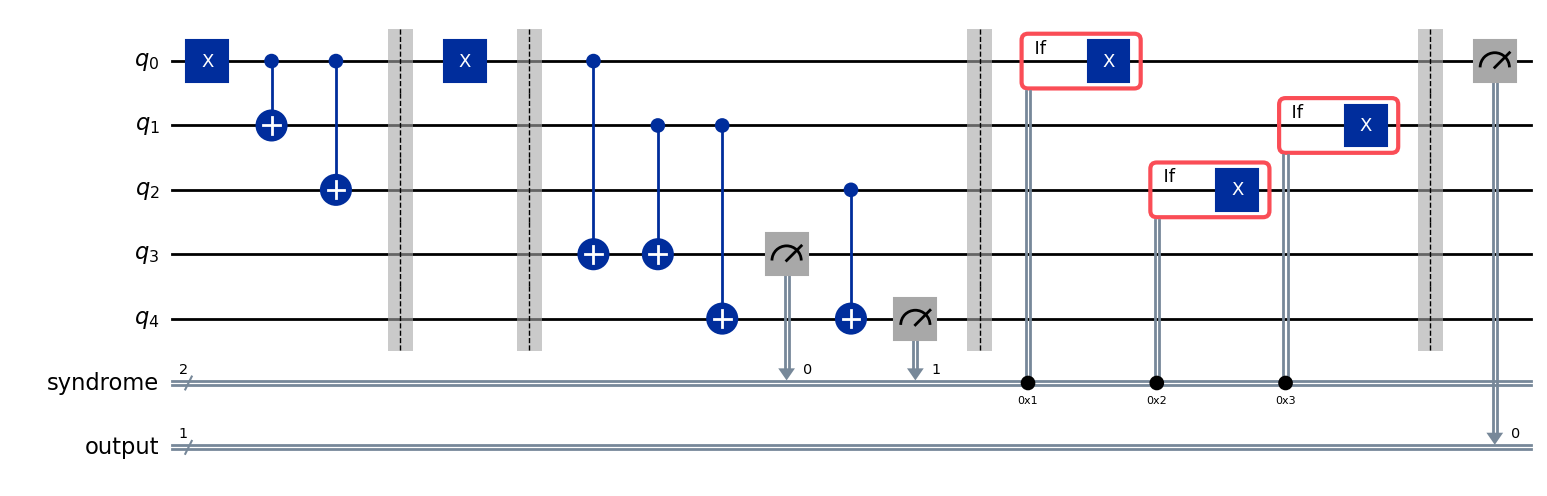

In [18]:
qc.draw(output='mpl')   